In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dakshbhalala/uci-air-quality-dataset")

print("Path to dataset files:", path)

100%|████████████████████████████████████████████████████████████████████████████████| 246k/246k [00:01<00:00, 235kB/s]

Extracting files...
Path to dataset files: C:\Users\Anshika\.cache\kagglehub\datasets\dakshbhalala\uci-air-quality-dataset\versions\1


Dataset Shape: (9471, 17)


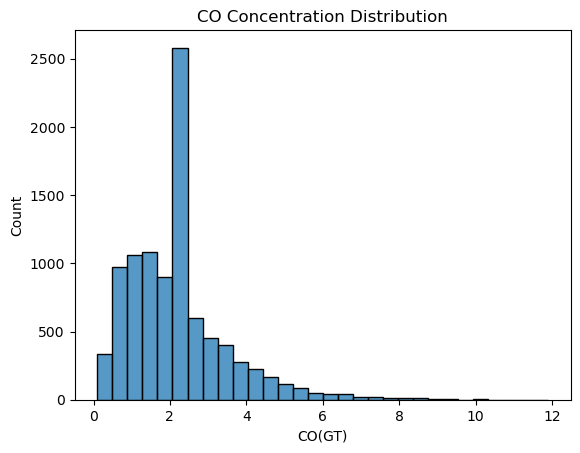

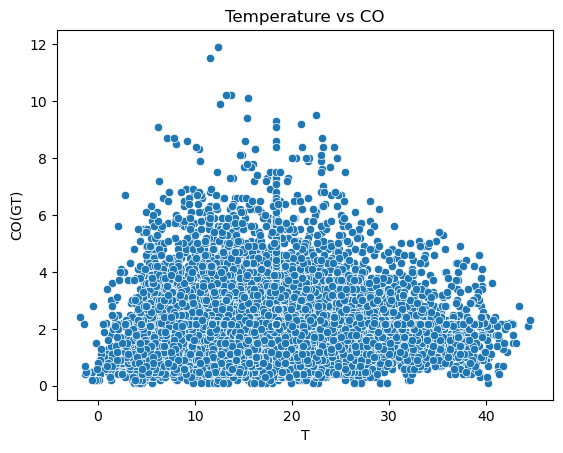

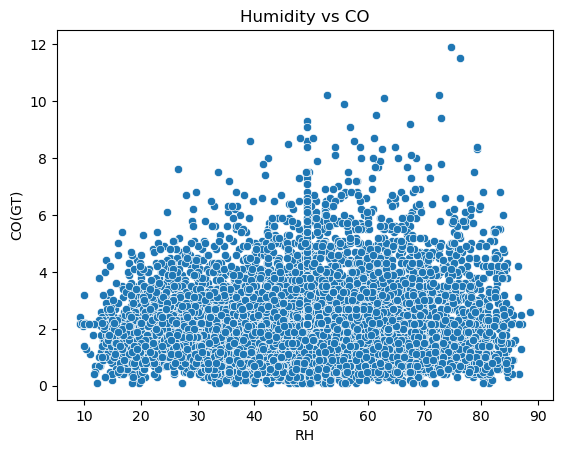

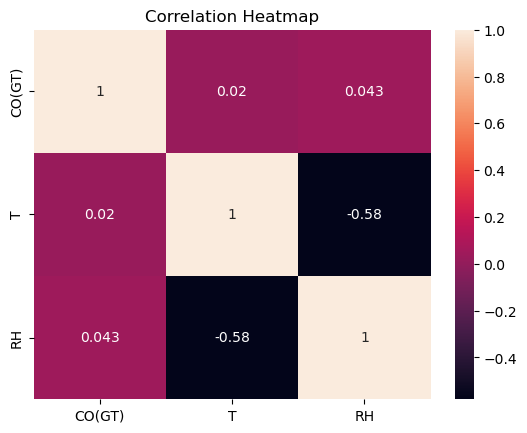

Mean Squared Error: 1.7487355801059503
R2 Score: 0.010461728411391369


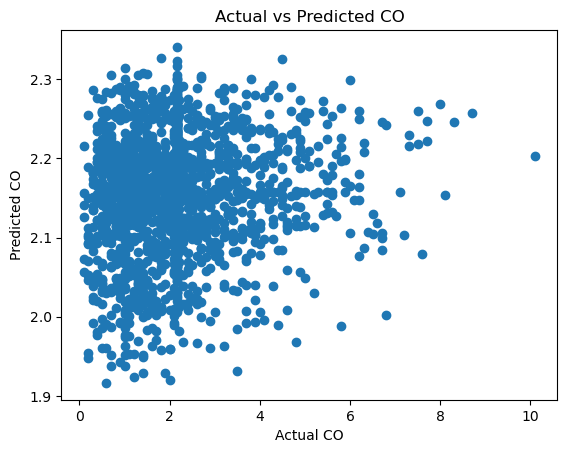

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# 1 Load Dataset
# -----------------------------

path = r"C:\Users\Anshika\.cache\kagglehub\datasets\dakshbhalala\uci-air-quality-dataset\versions\1\AirQualityUCI.csv"

df = pd.read_csv(path)

print("Dataset Shape:", df.shape)

# -----------------------------
# 2 Data Cleaning
# -----------------------------

# Remove useless columns
df = df.drop(['Unnamed: 15','Unnamed: 16'], axis=1)

# Replace -200 with NaN
df.replace(-200, pd.NA, inplace=True)

# Convert columns to numeric
df['CO(GT)'] = pd.to_numeric(df['CO(GT)'], errors='coerce')
df['T'] = pd.to_numeric(df['T'], errors='coerce')
df['RH'] = pd.to_numeric(df['RH'], errors='coerce')

# Fill missing values with mean
df['CO(GT)'] = df['CO(GT)'].fillna(df['CO(GT)'].mean())
df['T'] = df['T'].fillna(df['T'].mean())
df['RH'] = df['RH'].fillna(df['RH'].mean())

# -----------------------------
# 3 Visualization
# -----------------------------

plt.figure()
sns.histplot(df['CO(GT)'], bins=30)
plt.title("CO Concentration Distribution")
plt.show()

plt.figure()
sns.scatterplot(x='T', y='CO(GT)', data=df)
plt.title("Temperature vs CO")
plt.show()

plt.figure()
sns.scatterplot(x='RH', y='CO(GT)', data=df)
plt.title("Humidity vs CO")
plt.show()

plt.figure()
sns.heatmap(df[['CO(GT)','T','RH']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# -----------------------------
# 4 Feature Selection
# -----------------------------

X = df[['T','RH']]
y = df['CO(GT)']

# -----------------------------
# 5 Feature Scaling
# -----------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# 6 Train Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -----------------------------
# 7 Train Model
# -----------------------------

model = LinearRegression()
model.fit(X_train, y_train)

# -----------------------------
# 8 Prediction
# -----------------------------

pred = model.predict(X_test)

# -----------------------------
# 9 Evaluation
# -----------------------------

print("Mean Squared Error:", mean_squared_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

plt.figure()
plt.scatter(y_test, pred)
plt.xlabel("Actual CO")
plt.ylabel("Predicted CO")
plt.title("Actual vs Predicted CO")
plt.show()